# AI-Driven Warehouse Ground Floor System (RDC)

**Description:** Notebook overview and goals for storage, picking, coding, and routing on RDC.

This notebook implements a **ground-floor (RDC) warehouse engine** with:
- Intelligent storage allocation with strict rack priority
- Picking execution from location code to expedition zone
- Physical location coding/decoding
- Optimal routing using **Dijkstra** on a 4-direction grid

> Note: Dijkstra is a shortest-path algorithm without heuristic.

## 1) Core Models and Spatial Matrix
**Description:** Defines the RDC grid object model, cell types, and navigation matrix blueprint.
Each cell is an object containing coordinates, type, walkability, zone/rack metadata, floor, and occupancy state.

In [1]:
# Description: Core data structures and RDC matrix generation.

from __future__ import annotations

from dataclasses import dataclass
from enum import Enum
import heapq
import re
from typing import Dict, List, Optional, Tuple

Coordinate = Tuple[int, int]


class CellType(str, Enum):
    AISLE = "aisle"
    RACK = "rack"
    RACK_ACCESS = "rack_access"
    WALL = "wall"
    PILLAR = "pillar"
    EXPEDITION = "expedition"
    MONTRE_DE_CHARGE = "montre_de_charge"
    BUREAU = "bureau"
    ELEVATOR = "elevator"


@dataclass
class Cell:
    x: int
    y: int
    cell_type: CellType
    walkable: bool
    rack_id: Optional[str] = None
    zone: Optional[str] = None
    floor: int = 0
    occupied: bool = False


@dataclass
class PalletSlot:
    rack_id: str
    segment: int
    level: str
    column: int
    depth: int
    access_coordinate: Coordinate
    occupied: bool = False

    @property
    def key(self) -> Tuple[str, int, str, int, int]:
        return self.rack_id, self.segment, self.level, self.column, self.depth


@dataclass
class Rack:
    rack_id: str
    body_cells: List[Coordinate]
    access_cells: Dict[Tuple[int, int], Coordinate]
    zone: str


class NavigationMatrix:
    def __init__(self, width: int, height: int, floor: int = 0) -> None:
        self.width = width
        self.height = height
        self.floor = floor
        self.grid: List[List[Cell]] = [
            [
                Cell(x=x, y=y, cell_type=CellType.AISLE, walkable=True, floor=floor)
                for x in range(width)
            ]
            for y in range(height)
        ]
        self._build_default_blueprint()

    def in_bounds(self, coord: Coordinate) -> bool:
        x, y = coord
        return 0 <= x < self.width and 0 <= y < self.height

    def get_cell(self, coord: Coordinate) -> Cell:
        x, y = coord
        return self.grid[y][x]

    def set_cell(
        self,
        coord: Coordinate,
        cell_type: CellType,
        walkable: bool,
        rack_id: Optional[str] = None,
        zone: Optional[str] = None,
        occupied: bool = False,
    ) -> None:
        x, y = coord
        self.grid[y][x] = Cell(
            x=x,
            y=y,
            cell_type=cell_type,
            walkable=walkable,
            rack_id=rack_id,
            zone=zone,
            floor=self.floor,
            occupied=occupied,
        )

    def neighbors_4(self, coord: Coordinate) -> List[Coordinate]:
        x, y = coord
        candidates = [(x + 1, y), (x - 1, y), (x, y + 1), (x, y - 1)]
        result: List[Coordinate] = []
        for nx, ny in candidates:
            if not self.in_bounds((nx, ny)):
                continue
            if self.get_cell((nx, ny)).walkable:
                result.append((nx, ny))
        return result

    def _fill_rect(
        self,
        x1: int,
        y1: int,
        x2: int,
        y2: int,
        cell_type: CellType,
        walkable: bool,
        zone: Optional[str] = None,
    ) -> None:
        for y in range(y1, y2 + 1):
            for x in range(x1, x2 + 1):
                self.set_cell((x, y), cell_type, walkable=walkable, zone=zone)

    def _build_default_blueprint(self) -> None:
        for x in range(self.width):
            self.set_cell((x, 0), CellType.WALL, walkable=False, zone="shell")
            self.set_cell((x, self.height - 1), CellType.WALL, walkable=False, zone="shell")
        for y in range(self.height):
            self.set_cell((0, y), CellType.WALL, walkable=False, zone="shell")
            self.set_cell((self.width - 1, y), CellType.WALL, walkable=False, zone="shell")

        # Assenseur: 5 x 3 cells (left border)
        self._fill_rect(1, 3, 5, 5, CellType.ELEVATOR, walkable=True, zone="service")

        # Shift right-side blocks to the border (right-aligned)
        right_x2 = self.width - 2
        right_x1_15 = right_x2 - 14

        # Montre de charge: 15 x 8 cells (top-right border)
        self._fill_rect(right_x1_15, 2, right_x2, 9, CellType.MONTRE_DE_CHARGE, walkable=True, zone="inbound")

        # Bureau: 15 x 8 cells (bottom-right border)
        self._fill_rect(right_x1_15, 20, right_x2, 27, CellType.BUREAU, walkable=False, zone="office")

        # Expedition bands (right border)
        exp_x1 = right_x2 - 4
        self._fill_rect(exp_x1, 11, right_x2, 14, CellType.EXPEDITION, walkable=True, zone="outbound")
        self._fill_rect(exp_x1, 15, right_x2, 18, CellType.EXPEDITION, walkable=True, zone="outbound")

        for pillar in [
            (6, 2), (11, 2), (21, 2), (22, 2), (32, 2),
            (16, 8), (21, 8), (22, 8), (30, 8),
            (14, 12), (21, 12), (22, 12), (31, 12),
            (14, 18), (21, 18), (22, 18), (31, 18),
            (33, 19),
        ]:
            if self.in_bounds(pillar):
                self.set_cell(pillar, CellType.PILLAR, walkable=False, zone="structure")

    def to_object_matrix(self) -> List[List[dict]]:
        matrix: List[List[dict]] = []
        for row in self.grid:
            object_row: List[dict] = []
            for cell in row:
                object_row.append(
                    {
                        "x": cell.x,
                        "y": cell.y,
                        "cell_type": cell.cell_type.value,
                        "walkable": cell.walkable,
                        "rack_id": cell.rack_id,
                        "zone": cell.zone,
                        "floor": cell.floor,
                        "occupied": cell.occupied,
                    }
                )
            matrix.append(object_row)
        return matrix

## 2) Rack Manager, Slot Lookup, and Storage Policy
**Description:** Builds rack slots, decoding/encoding, and strict storage priority across racks and levels.
Implements strict storage priority across all configured rack IDs (A, B, C, ...), and within each rack: level then column then depth.

In [2]:
# Description: Rack logic, slot indexing, location codec, and storage policy engine.

class PhysicalLocationCodec:
    PICKING_REGEX = re.compile(r"^([G123])([A-Z])-([0-9]{2})-([1-3])(?:-D([1-3]))?(?:-S([0-9]{1,2}))?$")
    OTHER_REGEX = re.compile(r"^B([0-9]{2})-([A-Z]{2})$")
    GROUND_FLOOR = 0

    @staticmethod
    def encode_picking_zone(level: str, zone: str, rack_number: int, column: int) -> str:
        return f"{level}{zone}-{rack_number:02d}-{column}"

    @classmethod
    def decode_picking_zone(cls, code: str) -> Optional[dict]:
        match = cls.PICKING_REGEX.match(code)
        if not match:
            return None
        level, zone, rack_number, column, depth, segment = match.groups()
        return {
            "level": level,
            "zone": zone,
            "rack_number": int(rack_number),
            "column": int(column),
            "depth": int(depth) if depth is not None else None,
            "segment": int(segment) if segment is not None else 1,
        }

    @staticmethod
    def encode_other_storage(block_number: int, zone_code: str) -> str:
        return f"B{block_number:02d}-{zone_code.upper()}"

    @classmethod
    def decode_other_storage(cls, code: str) -> Optional[dict]:
        match = cls.OTHER_REGEX.match(code)
        if not match:
            return None
        block, zone_code = match.groups()
        return {
            "block_number": int(block),
            "floor_number": cls.GROUND_FLOOR,
            "zone_code": zone_code,
        }


class RackLogicalManager:
    LEVEL_PRIORITY = ["G", "1", "2", "3"]
    COLUMN_PRIORITY = [1, 2, 3]
    DEPTH_PRIORITY = [1, 2, 3]

    def __init__(
        self,
        nav_matrix: NavigationMatrix,
        rack_specs: Optional[Dict[str, Dict[str, object]]] = None,
    ) -> None:
        self.nav_matrix = nav_matrix
        self.racks: Dict[str, Rack] = {}
        self.slots_by_key: Dict[Tuple[str, int, str, int, int], PalletSlot] = {}
        self.slots_by_location_code: Dict[str, PalletSlot] = {}

        self.rack_specs = rack_specs or self._default_rack_specs()
        self.ordered_rack_ids = self._rack_priority_order(list(self.rack_specs.keys()))
        self.rack_id_to_number: Dict[str, int] = {
            rack_id: idx for idx, rack_id in enumerate(self.ordered_rack_ids, start=1)
        }
        self.number_to_rack_id: Dict[int, str] = {
            number: rack_id for rack_id, number in self.rack_id_to_number.items()
        }

        self._initialize_racks_and_slots()
        self._seed_initial_occupancy()

    @staticmethod
    def _default_rack_specs() -> Dict[str, Dict[str, object]]:
        # Spacing rule: keep separation between upper IDs and lower IDs,
        # not between each storage segment.
        def starts(count: int, first_start: int) -> List[int]:
            return [first_start + i * 3 for i in range(count)]

        top_first_start = 9
        bottom_first_start = 20  # 2-cell separation between upper and lower bands

        return {
            "W": {"x": 3, "y_starts": starts(5, 6), "zone": "A"},

            "T": {"x": 8, "y_starts": starts(2, top_first_start), "zone": "B"},
            "R": {"x": 10, "y_starts": starts(2, top_first_start), "zone": "B"},
            "P": {"x": 14, "y_starts": starts(2, top_first_start), "zone": "B"},
            "M": {"x": 16, "y_starts": starts(2, top_first_start), "zone": "B"},
            "I": {"x": 20, "y_starts": starts(2, top_first_start), "zone": "B"},
            "G": {"x": 22, "y_starts": starts(2, top_first_start), "zone": "B"},
            "E": {"x": 27, "y_starts": starts(2, top_first_start), "zone": "C"},
            "C": {"x": 33, "y_starts": starts(2, top_first_start), "zone": "C"},
            "A": {"x": 35, "y_starts": starts(2, top_first_start), "zone": "C"},

            "V": {"x": 8, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "S": {"x": 10, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "Q": {"x": 14, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "N": {"x": 16, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "K": {"x": 20, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "H": {"x": 22, "y_starts": starts(3, bottom_first_start), "zone": "B"},
            "F": {"x": 27, "y_starts": starts(3, bottom_first_start), "zone": "C"},
            "D": {"x": 29, "y_starts": starts(3, bottom_first_start), "zone": "C"},
            "B": {"x": 35, "y_starts": starts(3, bottom_first_start), "zone": "C"},
        }

    @staticmethod
    def _rack_priority_order(rack_ids: List[str]) -> List[str]:
        alphabetic = [chr(code) for code in range(ord("A"), ord("Z") + 1)]
        ordered = [rack_id for rack_id in alphabetic if rack_id in rack_ids]
        remaining = [rack_id for rack_id in rack_ids if rack_id not in ordered]
        return ordered + sorted(remaining)

    def rack_number(self, rack_id: str) -> int:
        return self.rack_id_to_number[rack_id]

    def rack_id_from_number(self, rack_number: int) -> Optional[str]:
        return self.number_to_rack_id.get(rack_number)

    def _initialize_racks_and_slots(self) -> None:
        for rack_id in self.ordered_rack_ids:
            spec = self.rack_specs[rack_id]
            x = int(spec["x"])
            y_starts = [int(y) for y in spec["y_starts"]]
            zone = str(spec["zone"])

            body_cells: List[Coordinate] = []
            access_cells: Dict[Tuple[int, int], Coordinate] = {}

            for segment_idx, y_start in enumerate(y_starts, start=1):
                for col in self.COLUMN_PRIORITY:
                    y = y_start + (col - 1)
                    body_coord = (x, y)
                    access_coord = (x - 1, y)

                    body_cells.append(body_coord)
                    access_cells[(segment_idx, col)] = access_coord

                    if self.nav_matrix.in_bounds(body_coord):
                        self.nav_matrix.set_cell(
                            body_coord,
                            CellType.RACK,
                            walkable=False,
                            rack_id=rack_id,
                            zone=zone,
                        )
                    if self.nav_matrix.in_bounds(access_coord):
                        self.nav_matrix.set_cell(
                            access_coord,
                            CellType.RACK_ACCESS,
                            walkable=True,
                            rack_id=rack_id,
                            zone=zone,
                        )

            self.racks[rack_id] = Rack(
                rack_id=rack_id,
                body_cells=body_cells,
                access_cells=access_cells,
                zone=zone,
            )

            for segment_idx, _ in enumerate(y_starts, start=1):
                for level in self.LEVEL_PRIORITY:
                    for col in self.COLUMN_PRIORITY:
                        for depth in self.DEPTH_PRIORITY:
                            slot = PalletSlot(
                                rack_id=rack_id,
                                segment=segment_idx,
                                level=level,
                                column=col,
                                depth=depth,
                                access_coordinate=access_cells[(segment_idx, col)],
                                occupied=False,
                            )
                            self.slots_by_key[slot.key] = slot

                            code = PhysicalLocationCodec.encode_picking_zone(
                                level=level,
                                zone=zone,
                                rack_number=self.rack_number(rack_id),
                                column=col,
                            )
                            self.slots_by_location_code[f"{code}-D{depth}-S{segment_idx}"] = slot

    def _seed_initial_occupancy(self) -> None:
        # (rack_id, segment, column)
        seeded = [
            ("A", 2, 3),
            ("C", 2, 3),
            ("E", 2, 3),
            ("M", 2, 3),
            ("T", 2, 3),
            ("F", 2, 1),
            ("N", 2, 1),
            ("V", 2, 1),
        ]
        for rack_id, segment, column in seeded:
            key = (rack_id, segment, "G", column, 1)
            slot = self.slots_by_key.get(key)
            if slot is not None:
                slot.occupied = True

    def get_slot(self, rack_id: str, segment: int, level: str, column: int, depth: int) -> PalletSlot:
        return self.slots_by_key[(rack_id, segment, level, column, depth)]

    def rack_ids_in_priority_order(self) -> List[str]:
        return self.ordered_rack_ids

    def all_slots_for_rack_in_priority(self, rack_id: str) -> List[PalletSlot]:
        ordered: List[PalletSlot] = []
        segment_count = len(self.rack_specs[rack_id]["y_starts"])
        for segment in range(1, segment_count + 1):
            for level in self.LEVEL_PRIORITY:
                for col in self.COLUMN_PRIORITY:
                    for depth in self.DEPTH_PRIORITY:
                        ordered.append(self.get_slot(rack_id, segment, level, col, depth))
        return ordered


class SlotLookupDictionary:
    def __init__(self, rack_manager: RackLogicalManager) -> None:
        self.by_key = rack_manager.slots_by_key
        self.by_location_code = rack_manager.slots_by_location_code

    def find_by_key(self, key: Tuple[str, int, str, int, int]) -> Optional[PalletSlot]:
        return self.by_key.get(key)

    def find_by_location_code(self, code: str) -> Optional[PalletSlot]:
        return self.by_location_code.get(code)


class StoragePolicyEngine:
    def __init__(self, rack_manager: RackLogicalManager) -> None:
        self.rack_manager = rack_manager

    def next_available_slot(self) -> Optional[PalletSlot]:
        for rack_id in self.rack_manager.rack_ids_in_priority_order():
            for slot in self.rack_manager.all_slots_for_rack_in_priority(rack_id):
                if not slot.occupied:
                    return slot
        return None

    @staticmethod
    def mark_occupied(slot: PalletSlot) -> None:
        slot.occupied = True

    @staticmethod
    def mark_empty(slot: PalletSlot) -> None:
        slot.occupied = False

## 3) Dijkstra Pathfinding, Picking Engine, and System Facade
**Description:** Implements shortest-path routing and end-to-end storage/picking orchestration.
Dijkstra computes optimal path cost on this uniform-cost grid while honoring blocked cells.

In [3]:
# Description: Dijkstra, picking workflow, and top-level warehouse system API.

class DijkstraPathfindingEngine:
    def __init__(self, nav_matrix: NavigationMatrix) -> None:
        self.nav_matrix = nav_matrix

    def shortest_path(self, start: Coordinate, goal: Coordinate) -> List[Coordinate]:
        if not self.nav_matrix.in_bounds(start) or not self.nav_matrix.in_bounds(goal):
            return []
        if not self.nav_matrix.get_cell(start).walkable or not self.nav_matrix.get_cell(goal).walkable:
            return []

        open_heap: List[Tuple[int, Coordinate]] = []
        heapq.heappush(open_heap, (0, start))

        came_from: Dict[Coordinate, Optional[Coordinate]] = {start: None}
        distance: Dict[Coordinate, int] = {start: 0}

        while open_heap:
            current_cost, current = heapq.heappop(open_heap)

            if current == goal:
                break

            if current_cost > distance.get(current, 10**9):
                continue

            for neighbor in self.nav_matrix.neighbors_4(current):
                candidate_cost = current_cost + 1
                if candidate_cost < distance.get(neighbor, 10**9):
                    distance[neighbor] = candidate_cost
                    came_from[neighbor] = current
                    heapq.heappush(open_heap, (candidate_cost, neighbor))

        if goal not in came_from:
            return []

        return self._reconstruct_path(came_from, goal)

    @staticmethod
    def _reconstruct_path(came_from: Dict[Coordinate, Optional[Coordinate]], goal: Coordinate) -> List[Coordinate]:
        path = [goal]
        current = goal
        while came_from[current] is not None:
            current = came_from[current]
            path.append(current)
        path.reverse()
        return path


class PickingEngine:
    def __init__(
        self,
        nav_matrix: NavigationMatrix,
        rack_manager: RackLogicalManager,
        slot_lookup: SlotLookupDictionary,
        storage_policy: StoragePolicyEngine,
        pathfinder: DijkstraPathfindingEngine,
        expedition_coord: Coordinate,
    ) -> None:
        self.nav_matrix = nav_matrix
        self.rack_manager = rack_manager
        self.slot_lookup = slot_lookup
        self.storage_policy = storage_policy
        self.pathfinder = pathfinder
        self.expedition_coord = expedition_coord

    def _shortest_path_on_ground_floor(self, start: Coordinate, goal: Coordinate) -> List[Coordinate]:
        return self.pathfinder.shortest_path(start, goal)

    def pick_and_deliver(self, worker_coord: Coordinate, location_code: str) -> dict:
        decoded = PhysicalLocationCodec.decode_picking_zone(location_code)
        if decoded is None:
            return {"ok": False, "reason": "invalid_location_code"}

        depth = decoded.get("depth") or 1
        segment = decoded.get("segment") or 1
        rack_id = self.rack_manager.rack_id_from_number(decoded["rack_number"])
        if rack_id is None:
            return {"ok": False, "reason": "unknown_rack_number"}

        key = (rack_id, segment, decoded["level"], decoded["column"], depth)
        slot = self.slot_lookup.find_by_key(key)

        if slot is None:
            return {"ok": False, "reason": "slot_not_found"}
        if not slot.occupied:
            return {"ok": False, "reason": "slot_already_empty"}

        path_to_slot = self._shortest_path_on_ground_floor(worker_coord, slot.access_coordinate)
        if not path_to_slot:
            return {"ok": False, "reason": "no_path_to_slot"}

        self.storage_policy.mark_empty(slot)

        path_to_expedition = self._shortest_path_on_ground_floor(slot.access_coordinate, self.expedition_coord)
        if not path_to_expedition:
            return {"ok": False, "reason": "no_path_to_expedition"}

        return {
            "ok": True,
            "slot_key": slot.key,
            "decoded": decoded,
            "path_to_slot": path_to_slot,
            "path_to_expedition": path_to_expedition,
            "delivered": True,
        }


class WarehouseGroundFloorSystem:
    def __init__(self) -> None:
        self.nav_matrix = NavigationMatrix(width=56, height=34, floor=0)
        self.rack_manager = RackLogicalManager(self.nav_matrix)
        self.slot_lookup = SlotLookupDictionary(self.rack_manager)
        self.storage_policy = StoragePolicyEngine(self.rack_manager)
        self.pathfinder = DijkstraPathfindingEngine(self.nav_matrix)

        # Landmarks aligned with border-shifted zones
        right_x2 = self.nav_matrix.width - 2
        right_x1_15 = right_x2 - 14
        self.montre_de_charge = (right_x1_15 + 7, 6)
        self.expedition = (right_x2 - 2, 12)

        self.other_zone_coordinates: Dict[str, Coordinate] = {
            "VR": (right_x1_15 + 2, 2),
            "EX": self.expedition,
            "MC": self.montre_de_charge,
        }

        self.picking_engine = PickingEngine(
            nav_matrix=self.nav_matrix,
            rack_manager=self.rack_manager,
            slot_lookup=self.slot_lookup,
            storage_policy=self.storage_policy,
            pathfinder=self.pathfinder,
            expedition_coord=self.expedition,
        )

    def _shortest_path_on_ground_floor(self, start: Coordinate, goal: Coordinate) -> List[Coordinate]:
        return self.pathfinder.shortest_path(start, goal)

    def storage_flow(self, worker_coord: Optional[Coordinate] = None) -> dict:
        start = worker_coord or self.montre_de_charge
        slot = self.storage_policy.next_available_slot()
        if slot is None:
            return {"ok": False, "reason": "all_slots_full"}

        path = self._shortest_path_on_ground_floor(start, slot.access_coordinate)
        if not path:
            return {"ok": False, "reason": "no_path_to_slot"}

        self.storage_policy.mark_occupied(slot)
        location_code = PhysicalLocationCodec.encode_picking_zone(
            level=slot.level,
            zone=self.rack_manager.racks[slot.rack_id].zone,
            rack_number=self.rack_manager.rack_number(slot.rack_id),
            column=slot.column,
        )

        return {
            "ok": True,
            "task": "storage",
            "from": start,
            "to": slot.access_coordinate,
            "slot_key": slot.key,
            "location_code": f"{location_code}-D{slot.depth}-S{slot.segment}",
            "path": path,
            "confirmed": True,
        }

    def picking_flow(self, worker_coord: Coordinate, location_code: str) -> dict:
        return self.picking_engine.pick_and_deliver(worker_coord, location_code)

    def decode_location_to_coordinate(self, location_code: str) -> Optional[Coordinate]:
        decoded = PhysicalLocationCodec.decode_picking_zone(location_code)
        if decoded:
            depth = decoded.get("depth") or 1
            segment = decoded.get("segment") or 1
            rack_id = self.rack_manager.rack_id_from_number(decoded["rack_number"])
            if rack_id is None:
                return None

            slot = self.slot_lookup.find_by_key(
                (rack_id, segment, decoded["level"], decoded["column"], depth)
            )
            return slot.access_coordinate if slot else None

        other = PhysicalLocationCodec.decode_other_storage(location_code)
        if other:
            return self.other_zone_coordinates.get(other["zone_code"])
        return None

## 4) Operational Demo
**Description:** Demonstrates one storage task and one picking task with explicit outputs.
Runs one storage from montre de charge to rack slot, then one picking from a given location code to expedition.

In [4]:
# Description: Demo execution for one storage example and one picking example.

system = WarehouseGroundFloorSystem()

# 1) Storage example: from montre de charge to the next available rack slot
storage_result = system.storage_flow()
print("Storage result:", storage_result)

# Specific given location (seeded occupied slot): rack A, segment 2, level G, column 3, depth 1
given_location_code = "GC-01-3-D1-S2"

# 2) Picking example: from worker start to specific slot, then to expedition
picking_result = system.picking_flow(worker_coord=(5, 8), location_code=given_location_code)
print("Picking result:", picking_result)

if storage_result.get("ok"):
    print("Stored to location:", storage_result["location_code"])

if picking_result.get("ok"):
    print("Picked from:", given_location_code)
    print("Delivered to expedition:", system.expedition)
else:
    print("Picking failed for location:", given_location_code)

Storage result: {'ok': True, 'task': 'storage', 'from': (47, 6), 'to': (34, 9), 'slot_key': ('A', 1, 'G', 1, 1), 'location_code': 'GC-01-1-D1-S1', 'path': [(47, 6), (46, 6), (45, 6), (44, 6), (43, 6), (42, 6), (41, 6), (40, 6), (39, 6), (38, 6), (37, 6), (36, 6), (35, 6), (34, 6), (34, 7), (34, 8), (34, 9)], 'confirmed': True}
Picking result: {'ok': True, 'slot_key': ('A', 2, 'G', 3, 1), 'decoded': {'level': 'G', 'zone': 'C', 'rack_number': 1, 'column': 3, 'depth': 1, 'segment': 2}, 'path_to_slot': [(5, 8), (5, 7), (6, 7), (7, 7), (8, 7), (9, 7), (10, 7), (11, 7), (12, 7), (13, 7), (14, 7), (15, 7), (16, 7), (17, 7), (18, 7), (19, 7), (20, 7), (21, 7), (22, 7), (23, 7), (24, 7), (25, 7), (26, 7), (27, 7), (28, 7), (29, 7), (30, 7), (31, 7), (31, 8), (32, 8), (33, 8), (34, 8), (34, 9), (34, 10), (34, 11), (34, 12), (34, 13), (34, 14)], 'path_to_expedition': [(34, 14), (34, 15), (35, 15), (36, 15), (36, 14), (36, 13), (36, 12), (37, 12), (38, 12), (39, 12), (40, 12), (41, 12), (42, 12), 

## 5) Ground Floor Grid Visualization
**Description:** Renders the RDC map and overlays paths for one storage example and one picking example.
Color map of the RDC matrix by cell type with occupied pallet highlights and route overlays for both flows.

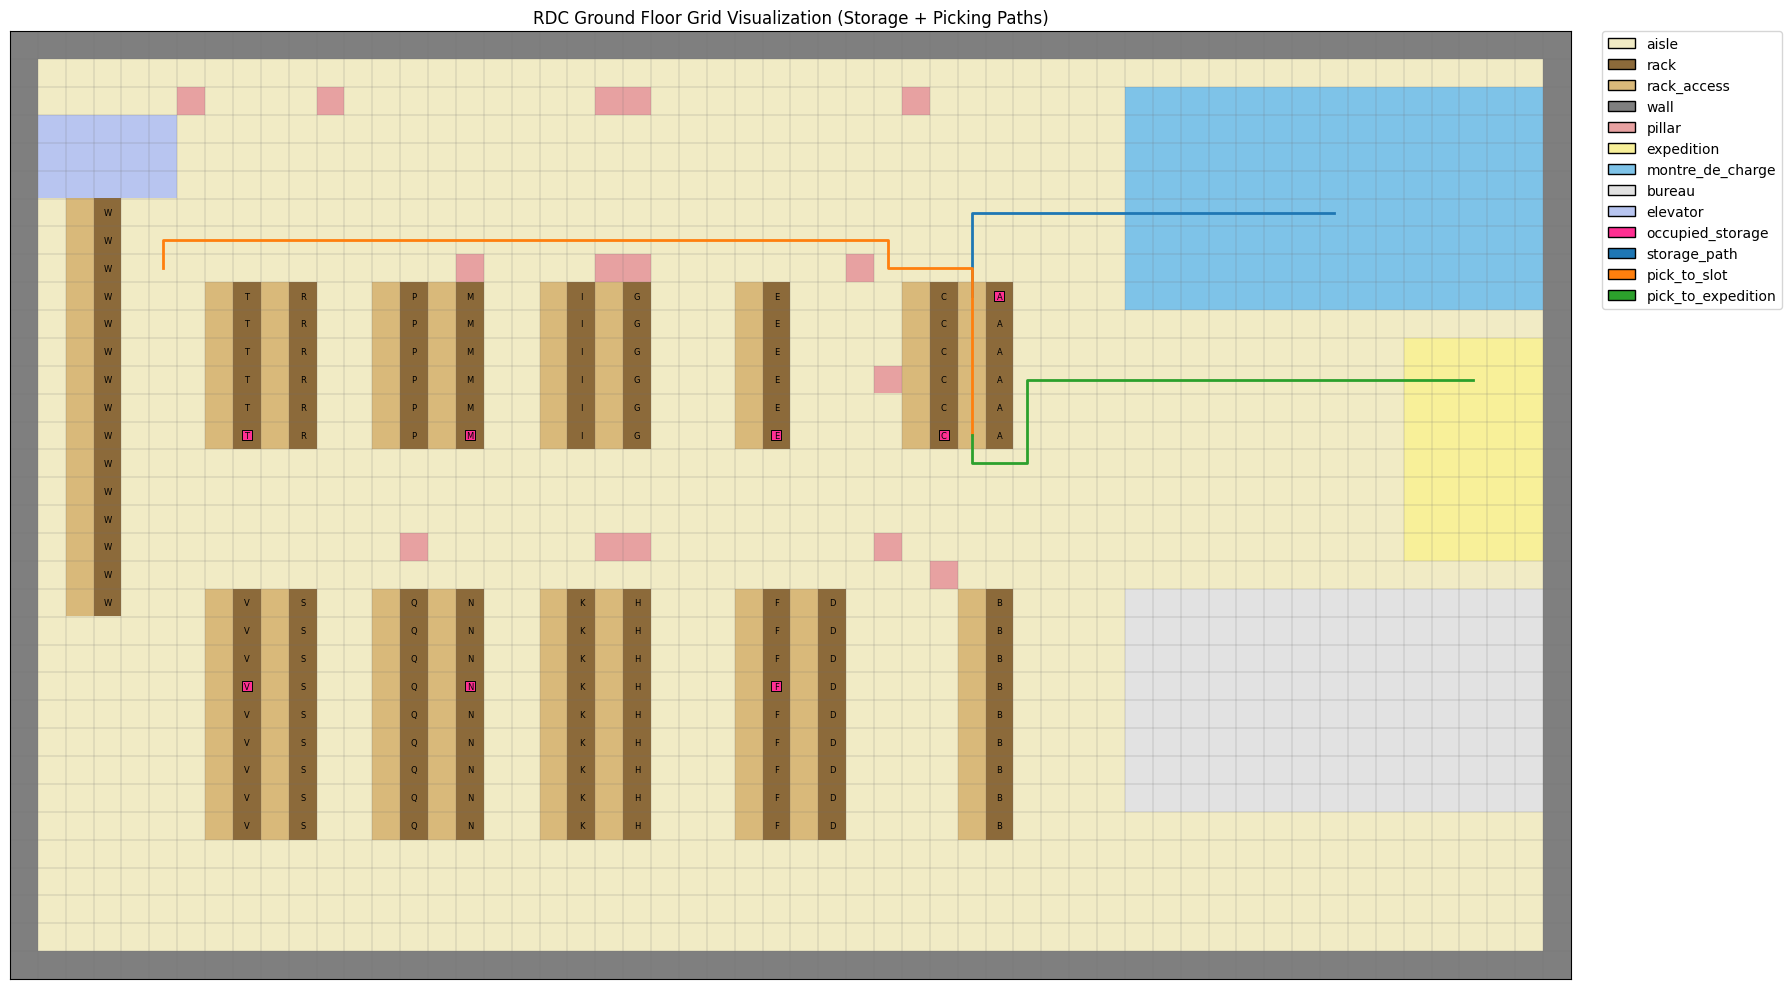

In [5]:
# Description: Visualization of RDC grid with occupied cells plus storage and picking paths.

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

system = WarehouseGroundFloorSystem()

# Run one storage and one picking example for path visualization
storage_example = system.storage_flow()
given_location_code = "GC-01-3-D1-S2"
picking_example = system.picking_flow(worker_coord=(5, 8), location_code=given_location_code)

matrix = system.nav_matrix.to_object_matrix()
height = len(matrix)
width = len(matrix[0])

cell_type_to_index = {
    "aisle": 0,
    "rack": 1,
    "rack_access": 2,
    "wall": 3,
    "pillar": 4,
    "expedition": 5,
    "montre_de_charge": 6,
    "bureau": 7,
    "elevator": 8,
}

index_to_color = {
    0: "#F1EBC5",  # aisle
    1: "#8C6A3A",  # rack body
    2: "#D9B97A",  # rack access
    3: "#7F7F7F",  # wall
    4: "#E7A1A1",  # pillar
    5: "#F8F099",  # expedition
    6: "#7EC3E8",  # montre de charge
    7: "#E2E2E2",  # bureau
    8: "#B8C5F0",  # elevator
}

grid_indices = [
    [cell_type_to_index[cell["cell_type"]] for cell in row]
    for row in matrix
]

cmap = ListedColormap([index_to_color[i] for i in range(len(index_to_color))])

fig, ax = plt.subplots(figsize=(18, 10))
ax.imshow(grid_indices, cmap=cmap, origin="upper", interpolation="nearest")

ax.set_xticks([x - 0.5 for x in range(1, width)], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, height)], minor=True)
ax.grid(which="minor", color="#707070", linestyle="-", linewidth=0.35, alpha=0.55)
ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

# Rack labels
for y in range(height):
    for x in range(width):
        cell = matrix[y][x]
        if cell["cell_type"] == "rack" and cell["rack_id"]:
            ax.text(x, y, cell["rack_id"], ha="center", va="center", fontsize=6, color="black")

# Highlight occupied stockages on the exact rack body cell (segment + column)
rm = system.rack_manager
occupied_x = []
occupied_y = []
occupied_seen = set()
for slot in rm.slots_by_key.values():
    if not slot.occupied:
        continue

    access = rm.racks[slot.rack_id].access_cells.get((slot.segment, slot.column))
    if access is None:
        continue

    rack_x, rack_y = access[0] + 1, access[1]
    if not (0 <= rack_x < width and 0 <= rack_y < height):
        continue

    point = (rack_x, rack_y)
    if point in occupied_seen:
        continue
    occupied_seen.add(point)

    occupied_x.append(rack_x)
    occupied_y.append(rack_y)

ax.scatter(
    occupied_x,
    occupied_y,
    c="#ff2f92",
    s=58,
    marker="s",
    edgecolors="black",
    linewidths=0.7,
    label="occupied_storage",
)

# Overlay storage path
if storage_example.get("ok") and storage_example.get("path"):
    sx = [coord[0] for coord in storage_example["path"]]
    sy = [coord[1] for coord in storage_example["path"]]
    ax.plot(sx, sy, color="#1f77b4", linewidth=2.0, label="storage_path")

# Overlay picking paths
if picking_example.get("ok") and picking_example.get("path_to_slot"):
    px1 = [coord[0] for coord in picking_example["path_to_slot"]]
    py1 = [coord[1] for coord in picking_example["path_to_slot"]]
    ax.plot(px1, py1, color="#ff7f0e", linewidth=2.0, label="pick_to_slot")

if picking_example.get("ok") and picking_example.get("path_to_expedition"):
    px2 = [coord[0] for coord in picking_example["path_to_expedition"]]
    py2 = [coord[1] for coord in picking_example["path_to_expedition"]]
    ax.plot(px2, py2, color="#2ca02c", linewidth=2.0, label="pick_to_expedition")

legend_items = [
    Patch(facecolor=index_to_color[idx], edgecolor="black", label=ctype)
    for ctype, idx in cell_type_to_index.items()
]
legend_items.append(Patch(facecolor="#ff2f92", edgecolor="black", label="occupied_storage"))
legend_items.append(Patch(facecolor="#1f77b4", edgecolor="black", label="storage_path"))
legend_items.append(Patch(facecolor="#ff7f0e", edgecolor="black", label="pick_to_slot"))
legend_items.append(Patch(facecolor="#2ca02c", edgecolor="black", label="pick_to_expedition"))
ax.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)

ax.set_title("RDC Ground Floor Grid Visualization (Storage + Picking Paths)")
plt.tight_layout()
plt.show()